<a href="https://colab.research.google.com/github/TeeMiles01/Data-Science-projects/blob/main/touristdataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("Historical data of Tanzania Tourism.csv")

In [3]:
data.head()

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,NaN,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,...,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,No,11.0,0.0,Cash,Yes,Friendly People,7790250.0
4,tour_1004,CHINA,1-24,NaN,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,7.0,4.0,Cash,Yes,No comments,1657500.0


In [4]:
data.columns[data.isnull().any()]

Index(['travel_with', 'total_female', 'total_male', 'most_impressing'], dtype='object')

In [5]:
data['total_female'] = data['total_female'].fillna(data['total_female'].median())
data['total_male'] = data['total_male'].fillna(data['total_male'].median())
data['travel_with'] = data['travel_with'].fillna('Unknown')
data['most_impressing'] = data['most_impressing'].fillna(data['most_impressing'].mode()[0])

In [6]:
data.columns[data.isnull().any()]

Index([], dtype='object')

In [7]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4804,False
4805,False
4806,False
4807,False


In [8]:
data.describe()

,total_female,total_male,night_mainland,night_zanzibar,total_cost
count,4809.000000,4809.000000,4809.000000,4809.000000,4.809000e+03
mean,0.926804,1.009565,8.488043,2.304429,8.114389e+06
std,1.287841,1.138273,10.427624,4.227080,1.222490e+07
min,0.000000,0.000000,0.000000,0.000000,4.900000e+04
25%,0.000000,1.000000,3.000000,0.000000,8.121750e+05
50%,1.000000,1.000000,6.000000,0.000000,3.397875e+06
75%,1.000000,1.000000,11.000000,4.000000,9.945000e+06
max,49.000000,44.000000,145.000000,61.000000,9.953288e+07


In [9]:
# Select only numeric columns first
numeric_data = data.select_dtypes(include='number')

# Compute pairwise correlation (Pearson by default)
correlation_matrix = numeric_data.corr()
print(correlation_matrix)

                total_female  total_male  night_mainland  night_zanzibar  \
total_female        1.000000    0.466985        0.031205        0.138541   
total_male          0.466985    1.000000       -0.041957        0.050315   
night_mainland      0.031205   -0.041957        1.000000       -0.118155   
night_zanzibar      0.138541    0.050315       -0.118155        1.000000   
total_cost          0.286058    0.184657        0.020473        0.145139   

                total_cost  
total_female      0.286058  
total_male        0.184657  
night_mainland    0.020473  
night_zanzibar    0.145139  
total_cost        1.000000  


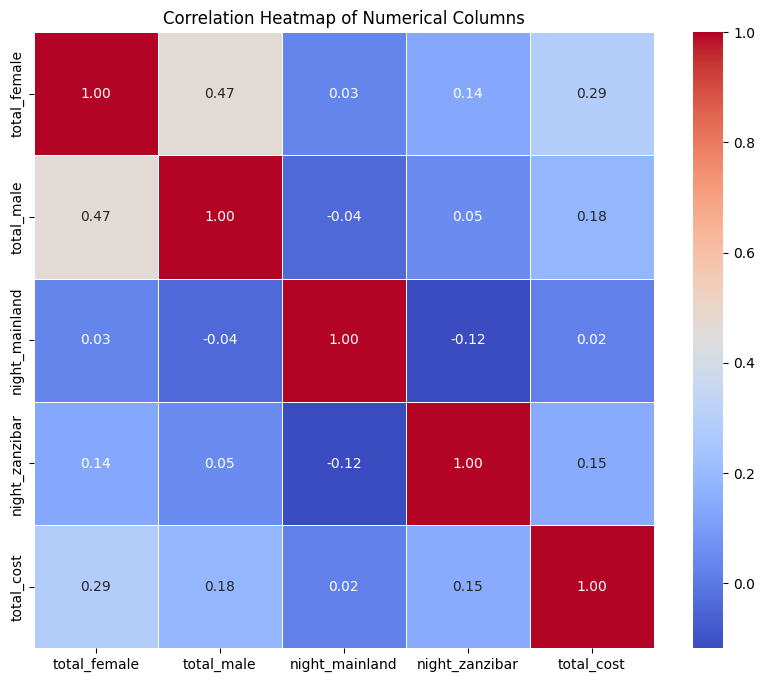

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

In [11]:
top_countries = data['country'].value_counts().head(3)
print(top_countries)

country
UNITED STATES OF AMERICA    695
UNITED KINGDOM              533
ITALY                       393
Name: count, dtype: int64


In [12]:
most_common_purpose = data.groupby('age_group')['purpose'].agg(lambda x: x.mode()[0])
print(most_common_purpose)

age_group
1-24     Leisure and Holidays
25-44    Leisure and Holidays
45-64    Leisure and Holidays
65+      Leisure and Holidays
Name: purpose, dtype: object


In [13]:
cost_by_country = data.groupby('country')['total_cost'].describe()
print(cost_by_country.sort_values('mean', ascending=False).head(10))


           count          mean           std         min          25%  \
country                                                                 
DOMINICA     1.0  3.315000e+07           NaN  33150000.0  33150000.00   
COSTARICA    1.0  2.718300e+07           NaN  27183000.0  27183000.00   
SLOVENIA     1.0  1.906237e+07           NaN  19062372.0  19062372.00   
TUNISIA      1.0  1.574625e+07           NaN  15746250.0  15746250.00   
AUSTRALIA  186.0  1.474802e+07  1.436988e+07     66300.0   3750093.75   
DENMARK     41.0  1.456879e+07  2.303191e+07    400000.0   1989000.00   
ISRAEL      16.0  1.430542e+07  1.765603e+07    165750.0   1802531.25   
RUSSIA       8.0  1.358321e+07  1.564106e+07   4077450.0   4765312.50   
COLOMBIA     3.0  1.331525e+07  7.152902e+06   5304000.0  10442250.00   
TAIWAN       9.0  1.321396e+07  9.608954e+06   1657500.0   8950500.00   

                  50%          75%         max  
country                                         
DOMINICA   33150000.0  33

In [14]:
cost_by_age = data.groupby('age_group')['total_cost'].describe()
print(cost_by_age)

            count          mean           std      min        25%         50%  \
age_group                                                                       
1-24        624.0  5.415205e+06  1.068684e+07  49725.0   569010.0   2602275.0   
25-44      2487.0  6.026176e+06  9.991599e+06  49000.0   600000.0   2486250.0   
45-64      1391.0  1.105093e+07  1.397950e+07  50000.0  1160250.0   5834400.0   
65+         307.0  1.721195e+07  1.563210e+07  50000.0  4972500.0  12845625.0   

                   75%         max  
age_group                           
1-24        5690100.00  92645962.5  
25-44       7293000.00  99532875.0  
45-64      15931933.25  95992659.0  
65+        25152562.50  77902500.0  


In [15]:
cost_by_purpose = data.groupby('purpose')['total_cost'].describe()
print(cost_by_purpose)

                                 count          mean           std      min  \
purpose                                                                       
Business                         671.0  1.782438e+06  4.056739e+06  49000.0   
Leisure and Holidays            2840.0  1.195114e+07  1.378463e+07  49725.0   
Meetings and Conference          312.0  2.453004e+06  4.080302e+06  53040.0   
Other                            128.0  1.592155e+06  5.475302e+06  50000.0   
Scientific and Academic           87.0  4.031990e+06  1.018641e+07  82875.0   
Visiting Friends and Relatives   633.0  3.190776e+06  8.163649e+06  49000.0   
Volunteering                     138.0  3.950565e+06  5.853944e+06  50000.0   

                                        25%        50%          75%  \
purpose                                                               
Business                         331500.000   680799.0   1657500.00   
Leisure and Holidays            3037525.000  7293000.0  16341445.33   
Meet